In [127]:
import pandas as pd

df = pd.read_csv("/content/crop disease predictioon - Form responses 1 (1).csv")  # change file name
print(df.head())

             timestamp   crop  crop year  season    area  production  \
0  29/04/2026 10:00:01   Rice       2010  Kharif  100000    180000.0   
1  29/04/2026 10:02:15   Rice       2011  Kharif  120000    210000.0   
2  29/04/2026 10:04:30  Wheat       2012    Rabi   90000    150000.0   
3  29/04/2026 10:06:45  Wheat       2013    Rabi   95000    160000.0   
4  29/04/2026 10:08:59   Rice       2014  Kharif  110000    200000.0   

   annual income  average temperature  max temperature  min temperature  \
0           1200                   25               35               18   
1           1300                   26               36               19   
2           1100                   24               34               17   
3           1150                   23               33               16   
4           1250                   27               37               20   

   fertilizer used  pesticide used  Column 13  
0             5000             200        NaN  
1             5200  

In [128]:
df.columns


Index(['timestamp', 'crop', 'crop year', 'season', 'area', 'production',
       'annual income', 'average temperature', 'max temperature',
       'min temperature', 'fertilizer used', 'pesticide used', 'Column 13'],
      dtype='object')

In [129]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            30 non-null     object 
 1   crop                 30 non-null     object 
 2   crop year            30 non-null     int64  
 3   season               30 non-null     object 
 4   area                 30 non-null     int64  
 5   production           30 non-null     float64
 6   annual income        30 non-null     int64  
 7   average temperature  30 non-null     int64  
 8   max temperature      30 non-null     int64  
 9   min temperature      30 non-null     int64  
 10  fertilizer used      30 non-null     int64  
 11  pesticide used       30 non-null     int64  
 12  Column 13            0 non-null      float64
dtypes: float64(2), int64(8), object(3)
memory usage: 3.2+ KB
None
         crop year           area     production  annual income  \
count    30.0

In [130]:
df.isnull().sum()

,0
timestamp,0
crop,0
crop year,0
season,0
area,0
production,0
annual income,0
average temperature,0
max temperature,0
min temperature,0


In [132]:
df = df.drop(columns=["timestamp", "Column 13"], errors='ignore')

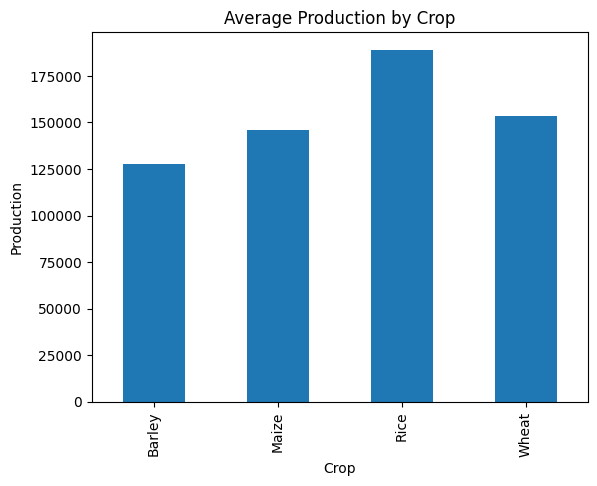

In [148]:
df_original = pd.read_csv("/content/crop disease predictioon - Form responses 1 (1).csv")   # load again

df_original.groupby("crop")["production"].mean().plot(kind="bar")
plt.title("Average Production by Crop")
plt.xlabel("Crop")
plt.ylabel("Production")
plt.show()

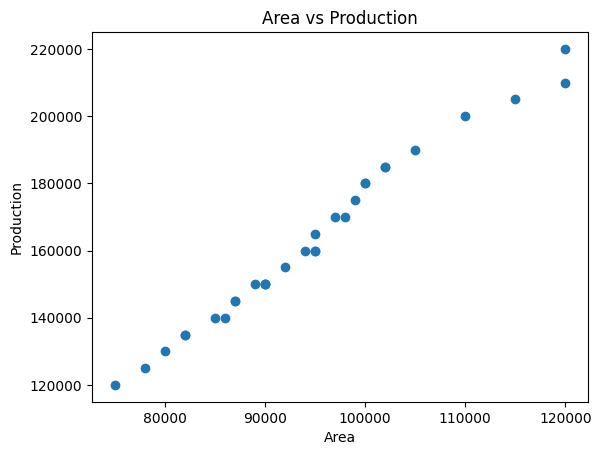

In [145]:
plt.scatter(df["area"], df["production"])
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production")
plt.show()

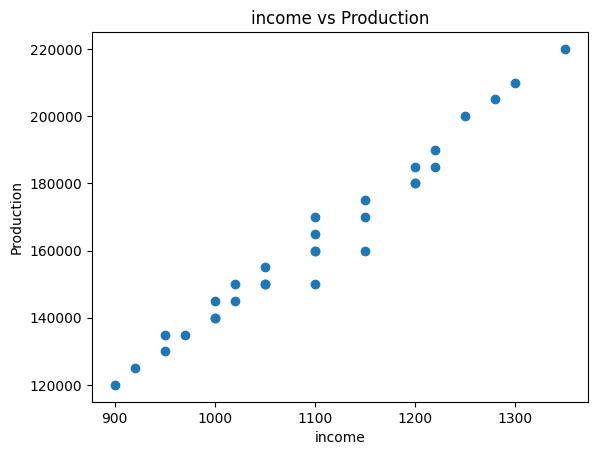

In [152]:
df_original = pd.read_csv("/content/crop disease predictioon - Form responses 1 (1).csv")
plt.scatter(df["annual income"], df["production"])
plt.xlabel("income")
plt.ylabel("Production")
plt.title("income vs Production")
plt.show()

In [133]:
df.head()

,crop,crop year,season,area,production,annual income,average temperature,max temperature,min temperature,fertilizer used,pesticide used
0,Rice,2010,Kharif,100000,180000.0,1200,25,35,18,5000,200
1,Rice,2011,Kharif,120000,210000.0,1300,26,36,19,5200,220
2,Wheat,2012,Rabi,90000,150000.0,1100,24,34,17,4800,180
3,Wheat,2013,Rabi,95000,160000.0,1150,23,33,16,4900,190
4,Rice,2014,Kharif,110000,200000.0,1250,27,37,20,5300,210


In [134]:
df.shape


(30, 11)

In [135]:
df = pd.get_dummies(df, columns=["crop", "season"], drop_first=True)

In [136]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [137]:
X = df.drop("production", axis=1)
y = df["production"]

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [139]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [140]:
y_pred = model.predict(X_test)

In [141]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3125.0
R2 Score: 0.9799159609120521


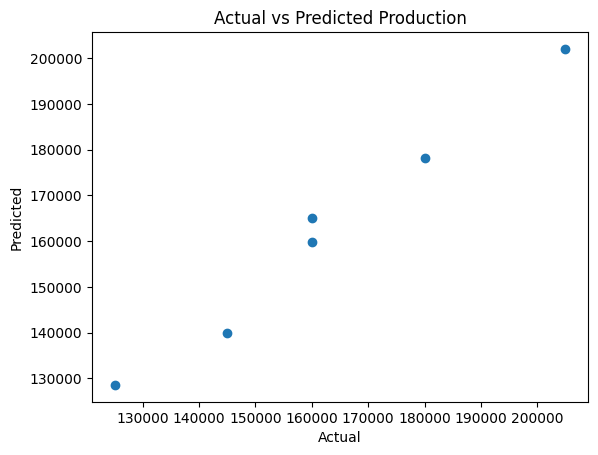

In [142]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Production")
plt.show()

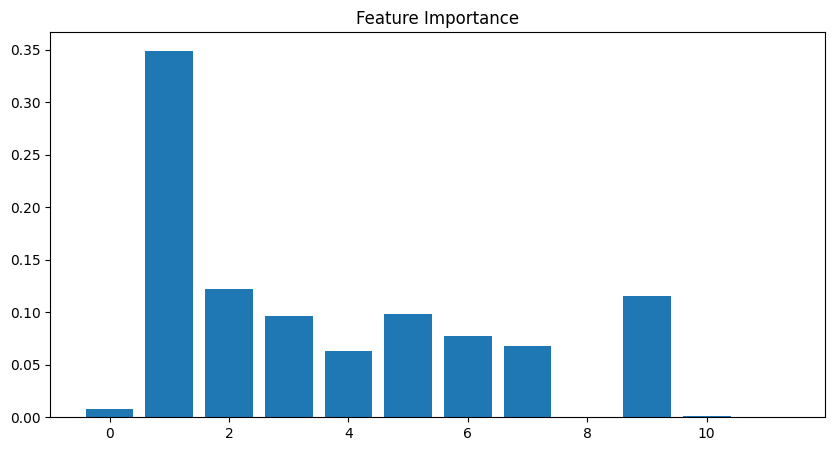

In [143]:
importances = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

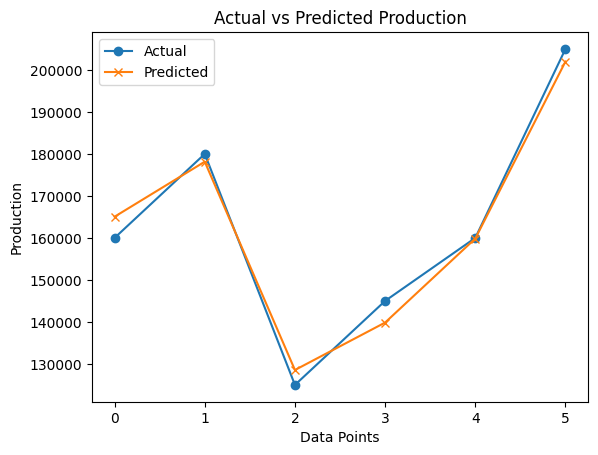

In [153]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.title("Actual vs Predicted Production")
plt.xlabel("Data Points")
plt.ylabel("Production")
plt.legend()

plt.show()